In [1]:
from all_imports import *

In [2]:
# 1. Haversine function to calculate distance in Kilometers
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    dLat = np.radians(lat2 - lat1)
    dLon = np.radians(lon2 - lon1)
    a = np.sin(dLat/2)**2 + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2)) * np.sin(dLon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    return R * c

# 2. Safely aggregate coordinates by zip code to prevent memory crashes
geo_agg = geolocation_df.groupby('geolocation_zip_code_prefix')[['geolocation_lat', 'geolocation_lng']].mean().reset_index()

# 3. Start with Order Items (Granularity = Per Item)
freight_df = orderItems_df[['order_id', 'product_id', 'seller_id', 'freight_value', 'price']].copy()

# 4. Attach Product Dimensions & Calculate Volume
freight_df = freight_df.merge(
    products_df[['product_id', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']], 
    on='product_id', how='left'
)
# Volume in cubic centimeters
freight_df['product_volume_cm3'] = freight_df['product_length_cm'] * freight_df['product_height_cm'] * freight_df['product_width_cm']

# 5. Attach Customer & Seller Zip Codes
freight_df = freight_df.merge(orders_df[['order_id', 'customer_id']], on='order_id', how='inner')
freight_df = freight_df.merge(customers_df[['customer_id', 'customer_zip_code_prefix']], on='customer_id', how='left')
freight_df = freight_df.merge(sellers_df[['seller_id', 'seller_zip_code_prefix']], on='seller_id', how='left')

# 6. Attach Coordinates
freight_df = freight_df.merge(
    geo_agg, left_on='customer_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left'
).rename(columns={'geolocation_lat': 'cust_lat', 'geolocation_lng': 'cust_lng'})

freight_df = freight_df.merge(
    geo_agg, left_on='seller_zip_code_prefix', right_on='geolocation_zip_code_prefix', how='left'
).rename(columns={'geolocation_lat': 'seller_lat', 'geolocation_lng': 'seller_lng'})

# 7. Drop missing coordinates/weights and Calculate Distance
freight_df.dropna(subset=['cust_lat', 'cust_lng', 'seller_lat', 'seller_lng', 'product_weight_g'], inplace=True)
freight_df['distance_km'] = haversine_distance(
    freight_df['seller_lat'], freight_df['seller_lng'], 
    freight_df['cust_lat'], freight_df['cust_lng']
)

# 8. Convert weight to kg for easier reading
freight_df['product_weight_kg'] = freight_df['product_weight_g'] / 1000

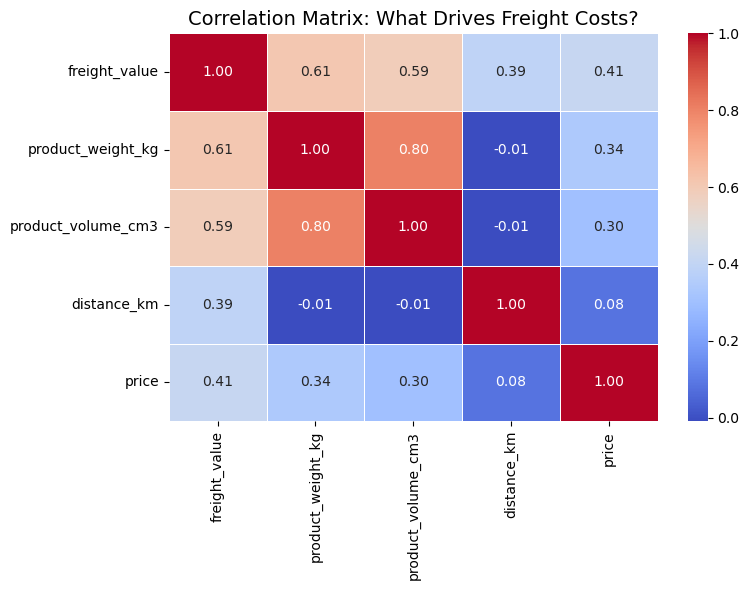

In [3]:
plt.figure(figsize=(8, 6))

# Select only numerical features for correlation
corr_features = freight_df[['freight_value', 'product_weight_kg', 'product_volume_cm3', 'distance_km', 'price']]
corr_matrix = corr_features.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix: What Drives Freight Costs?', fontsize=14)
plt.tight_layout()
plt.show()

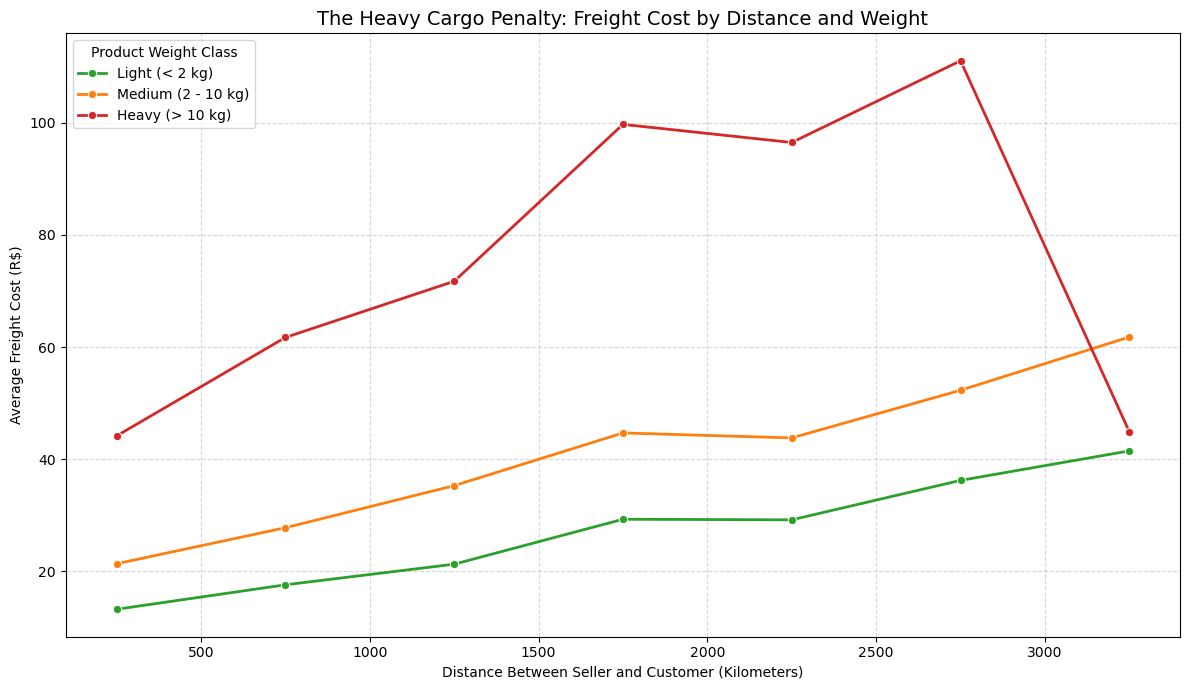

In [4]:
# Create Weight Categories
bins = [-np.inf, 2, 10, np.inf] # 0-2kg (Light), 2-10kg (Medium), 10kg+ (Heavy)
labels = ['Light (< 2 kg)', 'Medium (2 - 10 kg)', 'Heavy (> 10 kg)']
freight_df['weight_class'] = pd.cut(freight_df['product_weight_kg'], bins=bins, labels=labels)

# Create Distance Bins (e.g., 0-500km, 500-1000km, etc.) to smooth out the scatter plot
freight_df['distance_bin'] = pd.cut(freight_df['distance_km'], bins=np.arange(0, 4000, 500), labels=np.arange(250, 3750, 500))

# Calculate average freight for each bin combination
freight_trend = freight_df.groupby(['distance_bin', 'weight_class'], observed=False)['freight_value'].mean().reset_index()
freight_trend.dropna(inplace=True)

plt.figure(figsize=(12, 7))
sns.lineplot(
    data=freight_trend, 
    x='distance_bin', 
    y='freight_value', 
    hue='weight_class', 
    marker='o', 
    linewidth=2,
    palette=['#2ca02c', '#ff7f0e', '#d62728']
)

plt.title('The Heavy Cargo Penalty: Freight Cost by Distance and Weight', fontsize=14)
plt.xlabel('Distance Between Seller and Customer (Kilometers)')
plt.ylabel('Average Freight Cost (R$)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Product Weight Class')
plt.tight_layout()
plt.show()

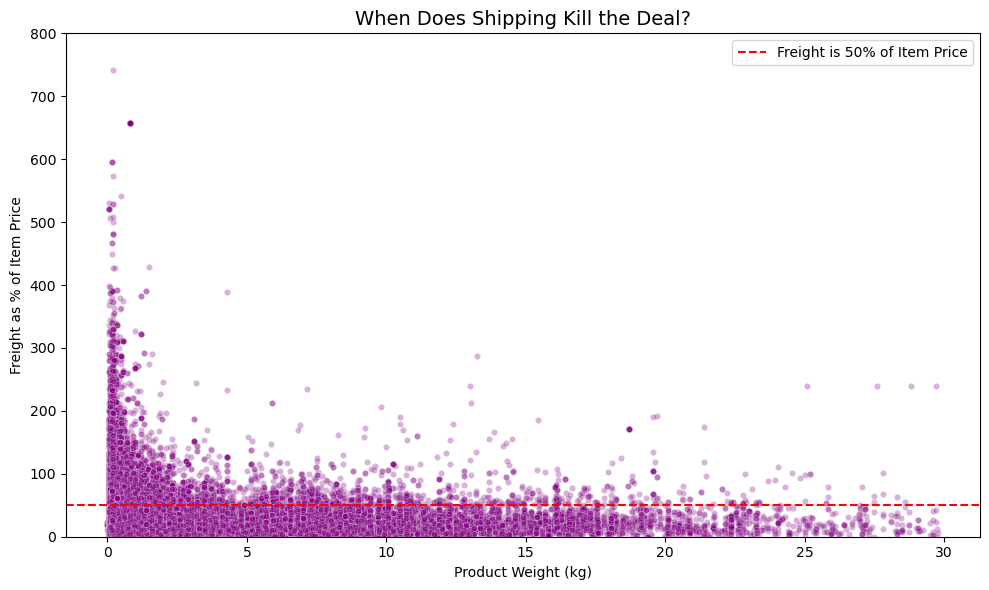

In [8]:
# Calculate freight as a percentage of product price
freight_df['freight_ratio_pct'] = (freight_df['freight_value'] / freight_df['price']) * 100

# Filter out extreme outliers for visualization (e.g., items over 50kg)
plot_df = freight_df[freight_df['product_weight_kg'] < 30]

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=plot_df,
    x='product_weight_kg',
    y='freight_ratio_pct',
    alpha=0.3,
    color='purple',
    s=20
)

# Draw a red line at 50% (where freight is half the cost of the item itself)
plt.axhline(50, color='red', linestyle='--', label='Freight is 50% of Item Price')

plt.title('When Does Shipping Kill the Deal?', fontsize=14)
plt.xlabel('Product Weight (kg)')
plt.ylabel('Freight as % of Item Price')
plt.ylim(0, 800) # Cap Y axis at 200% for readability
plt.legend()
plt.tight_layout()
plt.show()